## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle
import gc

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x0000021BE82D9910> [0]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'

In [4]:
years = range(2025, 2026)

In [5]:
timelines = []

for year in years:
    df = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_{year}_filled_mean_rain_shp.csv', encoding=enc)
    print(f'Year: {year} | {df.shape}')
    timelines.append(df)

Year: 2025 | (112024, 44)


In [6]:
# timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_2016-2018_filled.csv', encoding=enc)
# wnv_file = pd.read_csv(f'../../data/{NUTS0}_WNV_cases_GRID_2010-2021.csv', encoding=enc)

timeline_file = pd.concat(timelines, ignore_index=True, axis = 0)

In [7]:
del df
del timelines

gc.collect()

275

In [8]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,22.925360,36.229230,0,2025-01-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14345.000000,14068.000000,0.000000,1,14373.935484,14112.064516,14176.571429,13949.964286,14447.774194,14125.870968,14595.037037,14214.307692,0.000000,0.000000,0.000000,0.000000,2.000000,1,1
1,22.925360,36.229230,0,2025-01-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14379.000000,14098.000000,3.500000,2,14373.935484,14112.064516,14176.571429,13949.964286,14447.774194,14125.870968,14595.037037,14214.307692,3.500000,3.500000,3.500000,3.500000,2.000000,1,1
2,22.925360,36.229230,0,2025-01-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14362.000000,14098.000000,6.520000,3,14373.935484,14112.064516,14176.571429,13949.964286,14447.774194,14125.870968,14595.037037,14214.307692,10.020000,10.020000,10.020000,10.020000,2.000000,1,1
3,22.925360,36.229230,0,2025-01-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14362.000000,14098.000000,17.109999,4,14373.935484,14112.064516,14176.571429,13949.964286,14447.774194,14125.870968,14595.037037,14214.307692,27.129999,27.129999,27.129999,27.129999,2.000000,1,1
4,22.925360,36.229230,0,2025-01-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14357.000000,14250.000000,0.000000,5,14373.935484,14112.064516,14176.571429,13949.964286,14447.774194,14125.870968,14595.037037,14214.307692,27.129999,27.129999,27.129999,27.129999,2.000000,1,1


In [9]:
timeline_file.shape

(112024, 44)

In [10]:
subset = timeline_file[timeline_file['dt_placement'] >= '2025-05-01']

In [11]:
subset

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
120,22.925360,36.229230,0,2025-05-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,14373.935484,14112.064516,14176.571429,13949.964286,14447.774194,14125.870968,14595.037037,14214.307692,3.850000,5.750000,23.849999,416.129989,2.000000,1,1
121,22.925360,36.229230,0,2025-05-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14809.000000,14335.000000,0.550000,2,14373.935484,14112.064516,14176.571429,13949.964286,14447.774194,14125.870968,14595.037037,14214.307692,4.400000,6.300000,19.559999,416.679989,2.000000,1,1
122,22.925360,36.229230,0,2025-05-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14670.000000,14358.000000,1.420000,3,14373.935484,14112.064516,14176.571429,13949.964286,14447.774194,14125.870968,14595.037037,14214.307692,5.820000,7.720000,13.140000,418.099989,2.000000,1,1
123,22.925360,36.229230,0,2025-05-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,5,0.451382,0.129206,-0.418709,-0.129206,0.414638,0.118792,-0.389430,-0.118792,0.034453,0.021512,0.018692,0.021512,14958.000000,14358.000000,0.000000,4,14373.935484,14112.064516,14176.571429,13949.964286,14447.774194,14125.870968,14595.037037,14214.307692,2.440000,7.720000,13.140000,418.099989,2.000000,1,1
124,22.925360,36.229230,0,2025-05-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,5,0.451382,0.129206,-0.418709,-0.129206,0.414638,0.118792,-0.389430,-0.118792,0.034453,0.021512,0.018692,0.021512,14958.000000,14374.000000,0.000000,5,14373.935484,14112.064516,14176.571429,13949.964286,14447.774194,14125.870968,14595.037037,14214.307692,1.970000,7.720000,13.140000,418.099989,2.000000,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112019,24.055470,37.792330,736,2025-05-28,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,2025,5,0.291819,0.006188,-0.333558,-0.006188,0.281086,-0.003322,-0.338377,0.003322,0.017773,0.008624,0.007856,0.008624,NaN,NaN,NaN,28,14236.612903,14088.709677,14326.678571,13870.285714,14600.483871,14150.903226,14679.074074,14234.692308,0.000000,0.000000,2.630000,111.059997,2.000000,1,1
112020,24.055470,37.792330,736,2025-05-29,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,2025,5,0.291819,0.006188,-0.333558,-0.006188,0.281086,-0.003322,-0.338377,0.003322,0.017773,0.008624,0.007856,0.008624,NaN,NaN,NaN,29,14236.612903,14088.709677,14326.678571,13870.285714,14600.483871,14150.903226,14679.074074,14234.692308,0.000000,0.000000,2.170000,111.059997,2.000000,1,1
112021,24.055470,37.792330,736,2025-05-30,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,2025,5,0.291819,0.006188,-0.333558,-0.006188,0.281086,-0.003322,-0.338377,0.003322,0.017773,0.008624,0.007856,0.008624,NaN,NaN,NaN,30,14236.612903,14088.709677,14326.678571,13870.285714,14600.483871,14150.903226,14679.074074,14234.692308,0.000000,0.000000,2.170000,111.059997,2.000000,1,1
112022,24.055470,37.792330,736,2025-05-31,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,2025,5,0.291819,0.006188,-0.333558,-0.006188,0.281086,-0.003322,-0.338377,0.003322,0.017773,0.008624,0.007856,0.008624,NaN,NaN,NaN,31,14236.612903,14088.709677,14326.678571,13870.285714,14600.483871,14150.903226,14679.074074,14234.692308,0.000000,0.000000,2.17

In [12]:
latest_dates = timeline_file.groupby('cell_number')['dt_placement'].max().reset_index()

# Optionally rename the column
latest_dates.rename(columns={'dt_placement': 'latest_date'}, inplace=True)

print(latest_dates)

     cell_number latest_date
0              0  2025-06-01
1              1  2025-06-01
2              2  2025-06-01
3              3  2025-06-01
4              4  2025-06-01
..           ...         ...
732          732  2025-06-01
733          733  2025-06-01
734          734  2025-06-01
735          735  2025-06-01
736          736  2025-06-01

[737 rows x 2 columns]


In [13]:
# wnv_file.head()

In [14]:
# wnv_file.shape

In [15]:
try:
    timeline_file.drop(columns=['Unnamed: 0'], inplace=True)
except KeyError:
    print ("column not found")

column not found


In [16]:
temprature_cols = timeline_file.filter(regex='^lst_*').columns.tolist()

timeline_file[temprature_cols] = timeline_file[temprature_cols].apply(lambda x : x * 0.02 - 273.15)

In [17]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,22.925360,36.229230,0,2025-01-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.750000,8.210000,0.000000,1,14.328710,9.091290,10.381429,5.849286,15.805484,9.367419,18.750741,11.136154,0.000000,0.000000,0.000000,0.000000,2.000000,1,1
1,22.925360,36.229230,0,2025-01-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.430000,8.810000,3.500000,2,14.328710,9.091290,10.381429,5.849286,15.805484,9.367419,18.750741,11.136154,3.500000,3.500000,3.500000,3.500000,2.000000,1,1
2,22.925360,36.229230,0,2025-01-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.090000,8.810000,6.520000,3,14.328710,9.091290,10.381429,5.849286,15.805484,9.367419,18.750741,11.136154,10.020000,10.020000,10.020000,10.020000,2.000000,1,1
3,22.925360,36.229230,0,2025-01-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.090000,8.810000,17.109999,4,14.328710,9.091290,10.381429,5.849286,15.805484,9.367419,18.750741,11.136154,27.129999,27.129999,27.129999,27.129999,2.000000,1,1
4,22.925360,36.229230,0,2025-01-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.990000,11.850000,0.000000,5,14.328710,9.091290,10.381429,5.849286,15.805484,9.367419,18.750741,11.136154,27.129999,27.129999,27.129999,27.129999,2.000000,1,1


In [18]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [19]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)

timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [20]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [21]:
timeline_file

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,month_sin,month_cos
0,22.925360,36.229230,0,2025-01-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.750000,8.210000,0.000000,1,14.328710,9.091290,10.381429,5.849286,15.805484,9.367419,18.750741,11.136154,0.000000,0.000000,0.000000,0.000000,2.000000,1,1,10.980000,11.710000,8.115357,12.586452,14.943447,0.500000,0.866025
1,22.925360,36.229230,0,2025-01-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.430000,8.810000,3.500000,2,14.328710,9.091290,10.381429,5.849286,15.805484,9.367419,18.750741,11.136154,3.500000,3.500000,3.500000,3.500000,2.000000,1,1,11.620000,11.710000,8.115357,12.586452,14.943447,0.500000,0.866025
2,22.925360,36.229230,0,2025-01-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.090000,8.810000,6.520000,3,14.328710,9.091290,10.381429,5.849286,15.805484,9.367419,18.750741,11.136154,10.020000,10.020000,10.020000,10.020000,2.000000,1,1,11.450000,11.710000,8.115357,12.586452,14.943447,0.500000,0.866025
3,22.925360,36.229230,0,2025-01-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.090000,8.810000,17.109999,4,14.328710,9.091290,10.381429,5.849286,15.805484,9.367419,18.750741,11.136154,27.129999,27.129999,27.129999,27.129999,2.000000,1,1,11.450000,11.710000,8.115357,12.586452,14.943447,0.500000,0.866025
4,22.925360,36.229230,0,2025-01-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.990000,11.850000,0.000000,5,14.328710,9.091290,10.381429,5.849286,15.805484,9.367419,18.750741,11.136154,27.129999,27.129999,27.129999,27.129999,2.000000,1,1,12.920000,11.710000,8.115357,12.586452,14.943447,0.500000,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112019,24.055470,37.792330,736,2025-05-28,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,2025,5,0.291819,0.006188,-0.333558,-0.006188,0.281086,-0.003322,-0.338377,0.003322,0.017773,0.008624,0.007856,0.008624,NaN,NaN,NaN,28,11.582258,8.624194,13.383571,4.255714,18.859677,9.868065,20.431481,11.543846,0.000000,0.000000,2.630000,111.059997,2.000000,1,1,NaN,10.103226,8.819643,14.363871,15.987664,0.500000,-0.866025
112020,24.055470,37.792330,736,2025-05-29,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,2025,5,0.291819,0.006188,-0.333558,-0.006188,0.281086,-0.003322,-0.338377,0.003322,0.017773,0.008624,0.007856,0.008624,NaN,NaN,NaN,29,11.582258,8.624194,13.383571,4.255714,18.859677,9.868065,20.431481,11.543846,0.000000,0.000000,2.170000,111.059997,2.000000,1,1,NaN,10.103226,8.819643,14.363871,15.987664,0.500000,-0.866025
112021,24.055470,37.792330,736,2025-05-30,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,2025,5,0.291819,0.006188,-0.333558,-0.006188,0.281086,-0.003322,-0.338377,0.003322,0.017773,0.008624,0.007856,0.008624,NaN,NaN,NaN,30,11.582258,8.624194,13.383571,4.255714,18.859677,9.868065,20.431481,11.543846,0.000000,0.000000,2.170000,111.059997,2.000000,1,1,NaN,10.103226,8.819643,14.363871,15.987664,0.500000,-0.866025
112022,24.055470,37.792330,736,2025-05-31,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,20

In [22]:
timeline_file.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
timeline_file['date_string'] = timeline_file['month'].astype(str) + '-' + timeline_file['year'].astype(str)
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['date_string'], format='%m-%Y').dt.to_period('M')
timeline_file.drop(columns=['date_string'], inplace = True)

In [23]:
gc.collect()

17

In [24]:
grouped_by_month = timeline_file.drop(columns=['dt_placement_daily']).groupby(['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME'], as_index = False)

grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

In [25]:
del timeline_file
gc.collect()

0

In [26]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mean[['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME','x','y','MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_min[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_min', 'lst_night': 'lst_night_min'}),
                                     grouped_by_month_max[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_max', 'lst_night': 'lst_night_max'}),
                                     grouped_by_month_sum[['rainfall']].rename(columns={'rainfall':'rainfall_acc'})], axis=1)

In [27]:
del grouped_by_month
del grouped_by_month_mean
del grouped_by_month_min
del grouped_by_month_max
del grouped_by_month_sum
del grouped_by_month_last

gc.collect()

0

In [28]:
grouped_by_month_dataset.head()

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2025-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2025.000000,1.000000,0.432013,0.083407,-0.381338,-0.083407,0.389504,0.115818,-0.294944,-0.115818,0.061180,0.040032,0.066543,0.040032,14.328710,9.091290,11.710000,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,2.821613,0.890000,28.569999,87.469998,87.469998,10.870000,5.010000,15.710000,11.850000,87.469998
1,0,2025-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2025.000000,2.000000,0.403956,0.073849,-0.363431,-0.073849,0.389734,0.119886,-0.288719,-0.119886,0.050255,0.031638,0.054882,0.031638,10.381429,5.849286,8.115357,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,9.649285,120.549997,239.829994,270.709993,357.649991,4.970000,2.450000,15.090000,10.350000,270.179993
2,0,2025-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2025.000000,3.000000,0.419150,0.080605,-0.377346,-0.080605,0.411708,0.119997,-0.346138,-0.119997,0.050678,0.039874,0.067993,0.039874,15.805484,9.367419,12.586452,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,1.100645,8.750000,21.270000,33.899999,391.769990,9.330000,5.510000,21.930000,15.150000,34.119999
3,0,2025-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2025.000000,4.000000,0.467388,0.108242,-0.423855,-0.108242,0.419608,0.112332,-0.375822,-0.112332,0.037769,0.032868,0.039894,0.032868,18.750741,11.136154,15.036923,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,0.812000,5.160000,7.050000,24.359999,416.129989,13.770000,5.890000,22.950000,14.110000,24.359999
4,0,2025-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2025.000000,5.000000,0.482774,0.145795,-0.361620,-0.145795,0.463537,0.134610,-0.352952,-0.134610,0.034807,0.024555,0.014284,0.024555,24.262000,14.046000,19.154000,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,0.368333,0.000000,0.000000,2.210000,418.339989,20.250000,13.550000,26.010000,14.330000,2.210000


In [29]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2025-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2025.000000,1.000000,0.432013,0.083407,-0.381338,-0.083407,0.389504,0.115818,-0.294944,-0.115818,0.061180,0.040032,0.066543,0.040032,14.328710,9.091290,11.710000,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,2.821613,0.890000,28.569999,87.469998,87.469998,10.870000,5.010000,15.710000,11.850000,87.469998
1,0,2025-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2025.000000,2.000000,0.403956,0.073849,-0.363431,-0.073849,0.389734,0.119886,-0.288719,-0.119886,0.050255,0.031638,0.054882,0.031638,10.381429,5.849286,8.115357,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,9.649285,120.549997,239.829994,270.709993,357.649991,4.970000,2.450000,15.090000,10.350000,270.179993
2,0,2025-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2025.000000,3.000000,0.419150,0.080605,-0.377346,-0.080605,0.411708,0.119997,-0.346138,-0.119997,0.050678,0.039874,0.067993,0.039874,15.805484,9.367419,12.586452,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,1.100645,8.750000,21.270000,33.899999,391.769990,9.330000,5.510000,21.930000,15.150000,34.119999
3,0,2025-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2025.000000,4.000000,0.467388,0.108242,-0.423855,-0.108242,0.419608,0.112332,-0.375822,-0.112332,0.037769,0.032868,0.039894,0.032868,18.750741,11.136154,15.036923,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,0.812000,5.160000,7.050000,24.359999,416.129989,13.770000,5.890000,22.950000,14.110000,24.359999
4,0,2025-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2025.000000,5.000000,0.482774,0.145795,-0.361620,-0.145795,0.463537,0.134610,-0.352952,-0.134610,0.034807,0.024555,0.014284,0.024555,24.262000,14.046000,19.154000,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,0.368333,0.000000,0.000000,2.210000,418.339989,20.250000,13.550000,26.010000,14.330000,2.210000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4417,736,2025-02,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,24.055470,37.792330,2.000000,1.000000,1.000000,2025.000000,2.000000,0.312626,0.027928,-0.294584,-0.027928,0.333689,0.054139,-0.289171,-0.054139,0.045011,0.033203,0.042169,0.033203,13.383571,4.255714,8.819643,11.582258,13.383571,18.859677,20.431481,8.624194,4.255714,9.868065,11.543846,10.103226,8.819643,14.363871,15.987664,1.295357,17.950000,19.600000,36.269999,68.089999,10.570000,-2.430000,14.810000,9.730000,36.269999
4418,736,2025-03,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,24.055470,37.792330,2.000000,1.000000,1.000000,2025.000000,3.000000,0.310740,0.038288,-0.288193,-0.038288,0.343742,0.070648,-0.285768,-0.

In [30]:
grouped_by_month_dataset['lst_min'] = grouped_by_month_dataset.apply(lambda row: min(row['lst_day_min'], row['lst_night_min']), axis=1)
grouped_by_month_dataset['lst_max'] = grouped_by_month_dataset.apply(lambda row: max(row['lst_day_max'], row['lst_night_max']), axis=1)

In [31]:
grouped_by_month_dataset.drop(columns=['lst_day_min', 'lst_night_min', 'lst_day_max', 'lst_night_max'], inplace=True)

In [32]:
grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']] = grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']].astype(int)


In [33]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max
0,0,2025-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2025,1,0.432013,0.083407,-0.381338,-0.083407,0.389504,0.115818,-0.294944,-0.115818,0.061180,0.040032,0.066543,0.040032,14.328710,9.091290,11.710000,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,2.821613,0.890000,28.569999,87.469998,87.469998,87.469998,5.010000,15.710000
1,0,2025-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2025,2,0.403956,0.073849,-0.363431,-0.073849,0.389734,0.119886,-0.288719,-0.119886,0.050255,0.031638,0.054882,0.031638,10.381429,5.849286,8.115357,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,9.649285,120.549997,239.829994,270.709993,357.649991,270.179993,2.450000,15.090000
2,0,2025-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2025,3,0.419150,0.080605,-0.377346,-0.080605,0.411708,0.119997,-0.346138,-0.119997,0.050678,0.039874,0.067993,0.039874,15.805484,9.367419,12.586452,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,1.100645,8.750000,21.270000,33.899999,391.769990,34.119999,5.510000,21.930000
3,0,2025-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2025,4,0.467388,0.108242,-0.423855,-0.108242,0.419608,0.112332,-0.375822,-0.112332,0.037769,0.032868,0.039894,0.032868,18.750741,11.136154,15.036923,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,0.812000,5.160000,7.050000,24.359999,416.129989,24.359999,5.890000,22.950000
4,0,2025-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2025,5,0.482774,0.145795,-0.361620,-0.145795,0.463537,0.134610,-0.352952,-0.134610,0.034807,0.024555,0.014284,0.024555,24.262000,14.046000,19.154000,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,0.368333,0.000000,0.000000,2.210000,418.339989,2.210000,13.550000,26.010000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4417,736,2025-02,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,24.055470,37.792330,2,1,1,2025,2,0.312626,0.027928,-0.294584,-0.027928,0.333689,0.054139,-0.289171,-0.054139,0.045011,0.033203,0.042169,0.033203,13.383571,4.255714,8.819643,11.582258,13.383571,18.859677,20.431481,8.624194,4.255714,9.868065,11.543846,10.103226,8.819643,14.363871,15.987664,1.295357,17.950000,19.600000,36.269999,68.089999,36.269999,-2.430000,14.810000
4418,736,2025-03,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,24.055470,37.792330,2,1,1,2025,3,0.310740,0.038288,-0.288193,-0.038288,0.343742,0.070648,-0.285768,-0.070648,0.028545,0.027501,0.021693,0.027501,18.859677,9.868065,14.363871,11.582258,13.383571,18.859677,20.431481,8.624194,4.255714,9.868065,11.543846,10.103226,8.819643,14.363871,15.987664,0.929355,11.970000,20.410000,28.649999,96.899998,28.809999,4.090000,24.630000
4419,736,2025-04,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,24.055470,37.792330,2,1,1,2025,4,0.280492,0.007498,-0.281894,-0.0

### Add Geomorphological and Land Cover/Use

In [34]:
dataset_locations = grouped_by_month_dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [35]:
dataset_locations_per_year = grouped_by_month_dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [36]:
dataset_locations

,x,y
0,22.925360,36.229230
1,22.925360,36.319060
2,22.925360,36.337030
3,22.947520,36.193290
4,22.947520,36.211260
...,...,...
1016,24.055470,37.774360
1017,24.055470,37.774360
1018,24.055470,37.774360
1019,24.055470,37.792330


In [37]:
dataset_locations_per_year

,x,y,year
0,22.925360,36.229230,2025
1,22.925360,36.319060,2025
2,22.925360,36.337030,2025
3,22.947520,36.193290,2025
4,22.947520,36.211260,2025
...,...,...,...
1016,24.055470,37.774360,2025
1017,24.055470,37.774360,2025
1018,24.055470,37.774360,2025
1019,24.055470,37.792330,2025


In [38]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [39]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 2.183223232975093e-06
Max distance: 0.0004080402541026767


In [40]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_175584\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [41]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.925360,36.229230,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166
1,22.925360,36.319060,1765.480985,6926.111027,10,197.077012,274.126271,180.773995,0.000000,5.117582
2,22.925360,36.337030,1903.382813,7495.847864,7,235.289966,337.325945,186.904082,0.000000,1.487290
3,22.947520,36.193290,2106.538145,3337.921859,15,286.834685,337.529195,188.715719,0.000000,1.065844
4,22.947520,36.211260,2711.444137,4312.804250,4,126.014898,367.742367,184.864822,0.000000,1.846998
...,...,...,...,...,...,...,...,...,...,...
1016,24.055470,37.774360,2045.112663,134.017517,28,278.377388,82.546453,182.070048,0.000000,83.284376
1017,24.055470,37.774360,2045.112663,134.017517,28,278.377388,82.546453,182.070048,0.000000,83.284376
1018,24.055470,37.774360,2045.112663,134.017517,28,278.377388,82.546453,182.070048,0.000000,83.284376
1019,24.055470,37.792330,1561.708783,135.651666,8,197.391162,118.830309,177.711568,0.000000,79.889781


In [42]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [43]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [44]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [45]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.925360,36.229230,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166
1,22.925360,36.319060,1765.480985,6926.111027,10,197.077012,274.126271,180.773995,0.000000,5.117582
2,22.925360,36.337030,1903.382813,7495.847864,7,235.289966,337.325945,186.904082,0.000000,1.487290
3,22.947520,36.193290,2106.538145,3337.921859,15,286.834685,337.529195,188.715719,0.000000,1.065844
4,22.947520,36.211260,2711.444137,4312.804250,4,126.014898,367.742367,184.864822,0.000000,1.846998
...,...,...,...,...,...,...,...,...,...,...
1016,24.055470,37.774360,2045.112663,134.017517,28,278.377388,82.546453,182.070048,0.000000,83.284376
1017,24.055470,37.774360,2045.112663,134.017517,28,278.377388,82.546453,182.070048,0.000000,83.284376
1018,24.055470,37.774360,2045.112663,134.017517,28,278.377388,82.546453,182.070048,0.000000,83.284376
1019,24.055470,37.792330,1561.708783,135.651666,8,197.391162,118.830309,177.711568,0.000000,79.889781


In [46]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [47]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [48]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [49]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [50]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [51]:
landcover_2025 = landcover_2024 = landcover_2023 = landcover_2022

In [52]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2025
Min distance: 2.183223232975093e-06
Max distance: 0.0004080402541026767


In [53]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [54]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,22.925360,36.229230,2025,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
1,22.925360,36.319060,2025,21,76,20,76.000000,20,76,8,8,4,2,2,2,0
2,22.925360,36.337030,2025,11,85,10,81.000000,10,81,1,1,7,1,1,2,0
3,22.947520,36.193290,2025,22,86,20,86.000000,20,86,9,9,4,2,2,2,0
4,22.947520,36.211260,2025,31,91,30,91.000000,30,91,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016,24.055470,37.774360,2025,31,90,30,90.000000,30,90,10,10,1,6,6,2,0
1017,24.055470,37.774360,2025,31,90,30,90.000000,30,90,10,10,1,6,6,2,0
1018,24.055470,37.774360,2025,31,90,30,90.000000,30,90,10,10,1,6,6,2,0
1019,24.055470,37.792330,2025,31,89,30,89.000000,30,89,10,10,1,6,6,2,0


In [55]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int32
lc_prop1                 int64
lc_prop1_assessment      int64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment      int64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [56]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_geo, on=['x', 'y'], how='left')

In [57]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

### Add Bio Variables ###

In [58]:
bio_values_df = grouped_by_month_dataset[['cell_number','year','month','rainfall_acc','lst_min','lst_max']]

In [59]:
bio_values_df.head(15)

,cell_number,year,month,rainfall_acc,lst_min,lst_max
0,0,2025,1,87.469998,5.010000,15.710000
1,0,2025,2,270.179993,2.450000,15.090000
2,0,2025,3,34.119999,5.510000,21.930000
3,0,2025,4,24.359999,5.890000,22.950000
4,0,2025,5,2.210000,13.550000,26.010000
5,0,2025,6,0.000000,NaN,NaN
6,1,2025,1,86.339998,6.370000,16.730000
7,1,2025,2,253.089993,1.810000,16.550000
8,1,2025,3,43.549999,6.110000,23.690000
9,1,2025,4,39.049999,7.650000,23.990000


In [60]:
# wnv_file.head(5)

In [61]:
# wnv_file

In [62]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4422 entries, 0 to 4421
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype    
---  ------               --------------  -----    
 0   cell_number          4422 non-null   int64    
 1   dt_placement         4422 non-null   period[M]
 2   NUTS1_ID             4422 non-null   object   
 3   NUTS1_NAME           4422 non-null   object   
 4   NUTS2_ID             4422 non-null   object   
 5   NUTS2_NAME           4422 non-null   object   
 6   NUTS3_ID             4422 non-null   object   
 7   NUTS3_NAME           4422 non-null   object   
 8   LAU1_NAME            4422 non-null   object   
 9   x                    4422 non-null   float64  
 10  y                    4422 non-null   float64  
 11  MOUNT_TYPE           4422 non-null   int32    
 12  URBN_TYPE            4422 non-null   int32    
 13  COAST_TYPE           4422 non-null   int32    
 14  year                 4422 non-null   int32    
 15  mont

In [63]:
# wnv_file.info()

In [64]:
# wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [65]:
# wnv_file.info()

In [66]:
# wnv_file

In [67]:
# wnv_file['cases'].value_counts()

In [68]:
# wnv_file.cases.sum()

In [69]:
# merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'cell_code'] )
merged = grouped_by_month_dataset

In [70]:
merged

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,0,2025-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2025,1,0.432013,0.083407,-0.381338,-0.083407,0.389504,0.115818,-0.294944,-0.115818,0.061180,0.040032,0.066543,0.040032,14.328710,9.091290,11.710000,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,2.821613,0.890000,28.569999,87.469998,87.469998,87.469998,5.010000,15.710000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
1,0,2025-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2025,2,0.403956,0.073849,-0.363431,-0.073849,0.389734,0.119886,-0.288719,-0.119886,0.050255,0.031638,0.054882,0.031638,10.381429,5.849286,8.115357,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,9.649285,120.549997,239.829994,270.709993,357.649991,270.179993,2.450000,15.090000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
2,0,2025-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2025,3,0.419150,0.080605,-0.377346,-0.080605,0.411708,0.119997,-0.346138,-0.119997,0.050678,0.039874,0.067993,0.039874,15.805484,9.367419,12.586452,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,1.100645,8.750000,21.270000,33.899999,391.769990,34.119999,5.510000,21.930000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
3,0,2025-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2025,4,0.467388,0.108242,-0.423855,-0.108242,0.419608,0.112332,-0.375822,-0.112332,0.037769,0.032868,0.039894,0.032868,18.750741,11.136154,15.036923,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,0.812000,5.160000,7.050000,24.359999,416.129989,24.359999,5.890000,22.950000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
4,0,2025-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2025,5,0.482774,0.145795,-0.361620,-0.145795,0.463537,0.134610,-0.352952,-0.134610,0.034807,0.024555,0.014284,0.024555,24.262000,14.046000,19.154000,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,0.368333,0.000000,0.000000,2.210000,418.339989,2.210000,13.550000,26.010000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4417,736,2025-02,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,24.055470,3

In [71]:
# merged = fillna(merged,{'cases': 0})

In [72]:
# merged['cases'].value_counts()

In [73]:
# merged.cases.sum()

In [74]:
# merged = merged.astype({'cases': 'int'})

<Axes: >

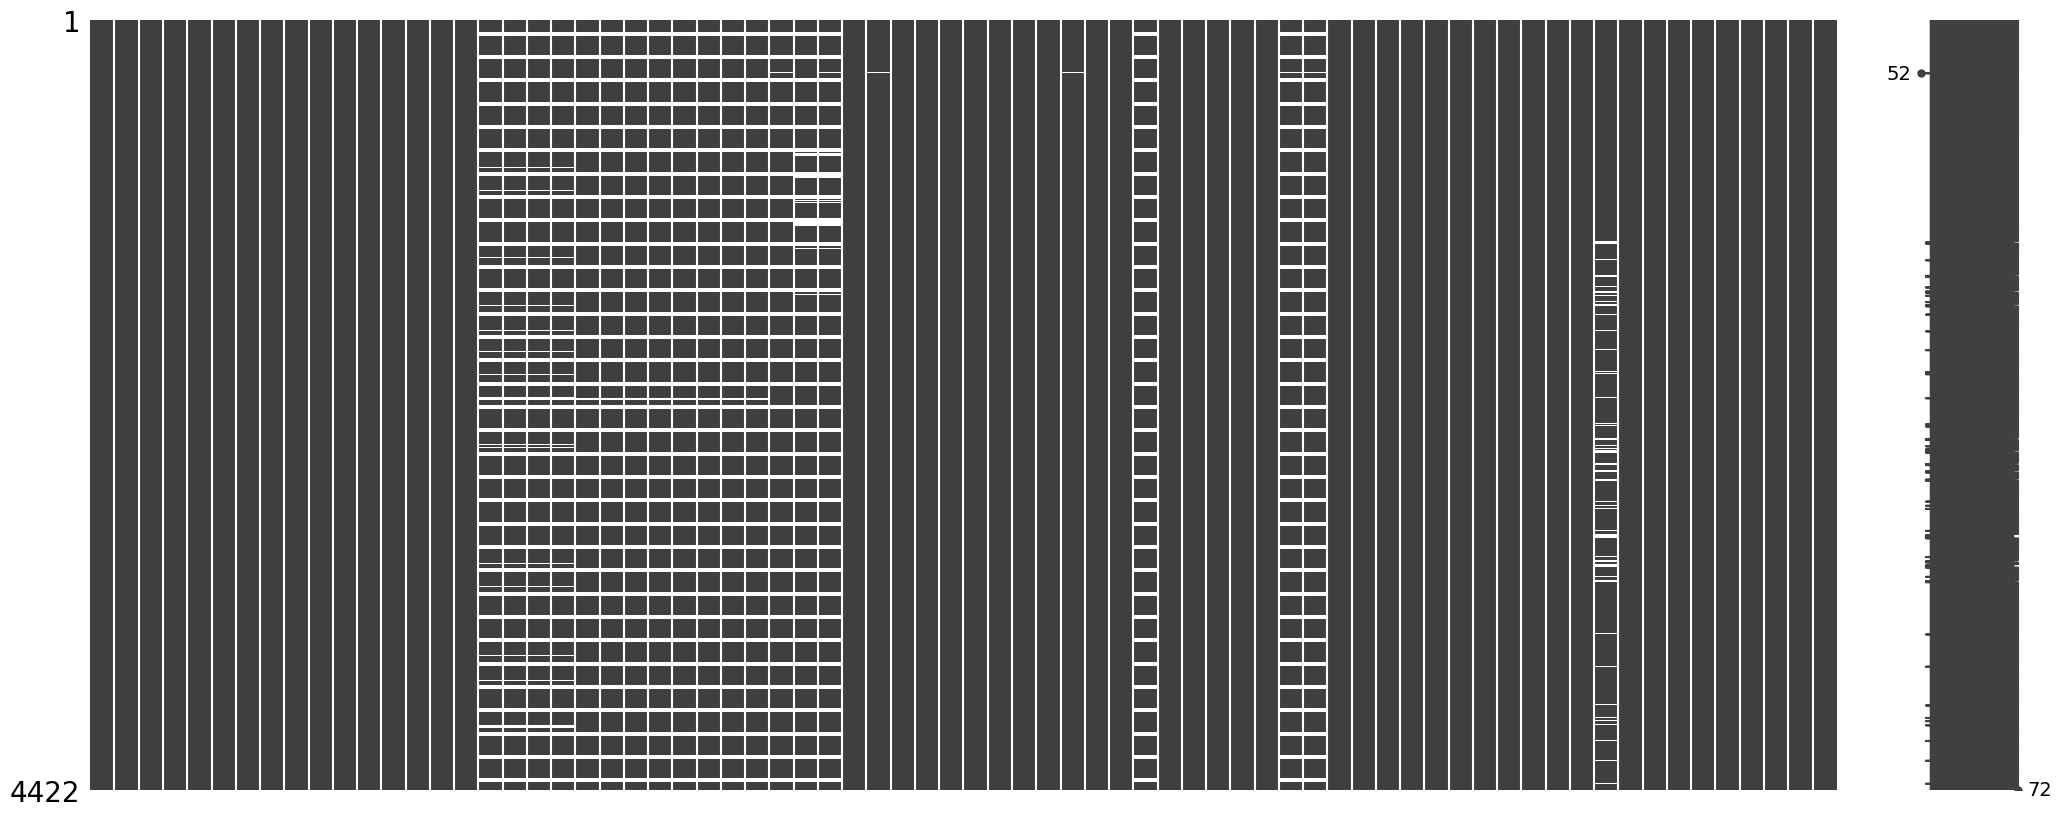

In [75]:
missingno.matrix(merged)

In [76]:
gc.collect()

0

In [77]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'lst_min', 'lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)
imputed_columns = ['lst_min', 'lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

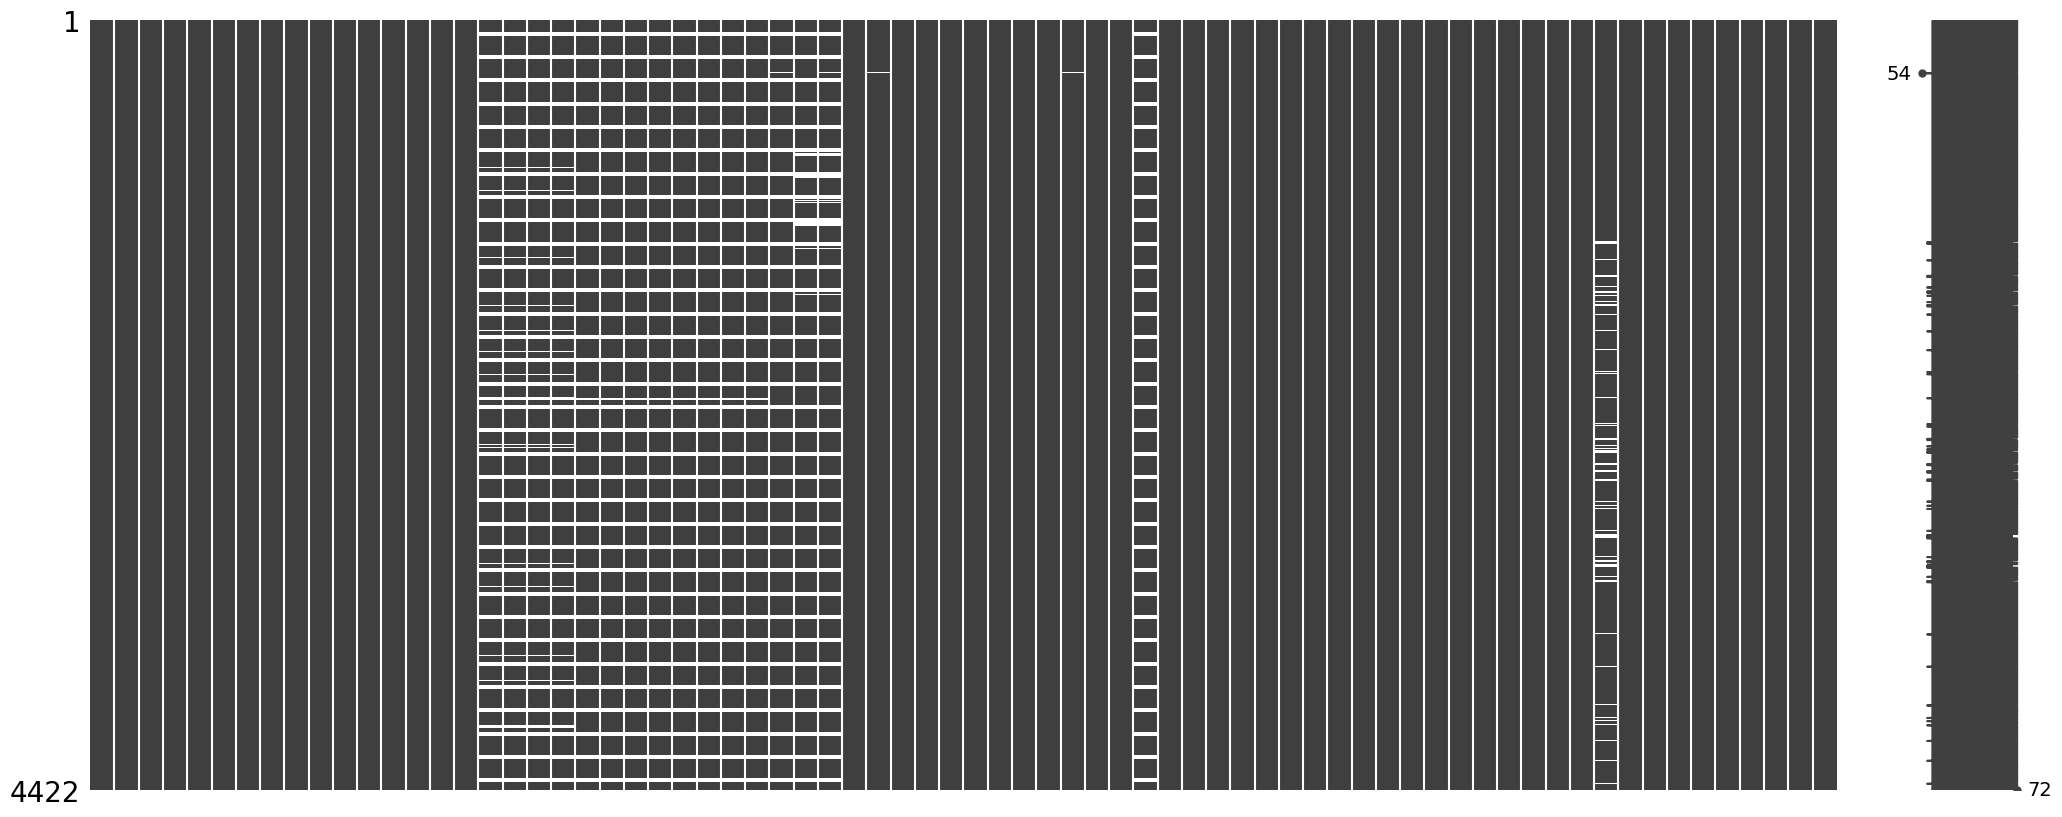

In [78]:
missingno.matrix(merged)

In [79]:
years = merged.year.unique()
years

array([2025])

In [80]:
cell_codes_un = merged.cell_number.unique()
cell_codes_un

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [81]:
rows = []
for year in years:
    for cell in cell_codes_un:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['cell_number'] == cell)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['rainfall_acc'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'cell_number': cell, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [82]:
biovars_df.head(20)

,cell_number,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,2025,13.916667,13.833333,57.638889,453.229155,26.000000,2.000000,24.000000,10.500000,17.333333,17.333333,10.500000,417.000000,270.000000,0.000000,146.344901,391.000000,26.000000,26.000000,391.000000
1,1,2025,14.166667,13.000000,59.090909,380.350715,23.000000,1.000000,22.000000,11.333333,17.000000,17.000000,11.333333,421.000000,253.000000,0.000000,133.651818,382.000000,39.000000,39.000000,382.000000
2,2,2025,14.416667,11.166667,55.833333,374.722119,24.000000,4.000000,20.000000,11.500000,17.333333,17.333333,11.500000,421.000000,253.000000,0.000000,133.651818,382.000000,39.000000,39.000000,382.000000
3,3,2025,14.083333,13.833333,57.638889,430.600356,26.000000,2.000000,24.000000,10.666667,17.500000,17.500000,10.666667,340.000000,212.000000,0.000000,140.390333,327.000000,13.000000,13.000000,327.000000
4,4,2025,14.166667,14.000000,56.000000,445.720391,26.000000,1.000000,25.000000,10.666667,17.666667,17.666667,10.666667,417.000000,270.000000,0.000000,146.344901,391.000000,26.000000,26.000000,391.000000
5,5,2025,13.583333,15.166667,48.924731,549.014268,27.000000,-4.000000,31.000000,9.333333,17.833333,17.833333,9.333333,417.000000,270.000000,0.000000,146.344901,391.000000,26.000000,26.000000,391.000000
6,6,2025,13.333333,15.333333,54.761905,495.647724,26.000000,-2.000000,28.000000,9.833333,16.833333,16.833333,9.833333,417.000000,270.000000,0.000000,146.344901,391.000000,26.000000,26.000000,391.000000
7,7,2025,13.500000,15.000000,53.571429,464.758002,25.000000,-3.000000,28.000000,10.333333,16.666667,16.666667,10.333333,417.000000,270.000000,0.000000,146.344901,391.000000,26.000000,26.000000,391.000000
8,8,2025,13.166667,14.666667,56.410256,456.800467,23.000000,-3.000000,26.000000,10.000000,16.333333,16.333333,10.000000,417.000000,270.000000,0.000000,146.344901,391.000000,26.000000,26.000000,391.000000
9,9,2025,13.833333,12.666667,60.317460,398.329847,23.000000,2.000000,21.000000,10.666667,17.000000,17.000000,10.666667,421.000000,253.000000,0.000000,133.651818,382.000000,39.000000,39.000000,382.000000


In [83]:
merged = pd.merge(merged, biovars_df,  how='left', on=['cell_number', 'year'])

In [84]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2024) & (merged['cell_number'] == 0)]

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19


In [85]:
df_demographics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [86]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1763,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1764,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1765,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000
1766,EL653,2023,14067.000000,71993.000000,29360.000000,115420.000000,13393.000000,67069.000000,32564.000000,113026.000000


In [87]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [88]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1763,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1764,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1765,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000
1766,EL653,2023,14067.000000,71993.000000,29360.000000,115420.000000,13393.000000,67069.000000,32564.000000,113026.000000


In [89]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

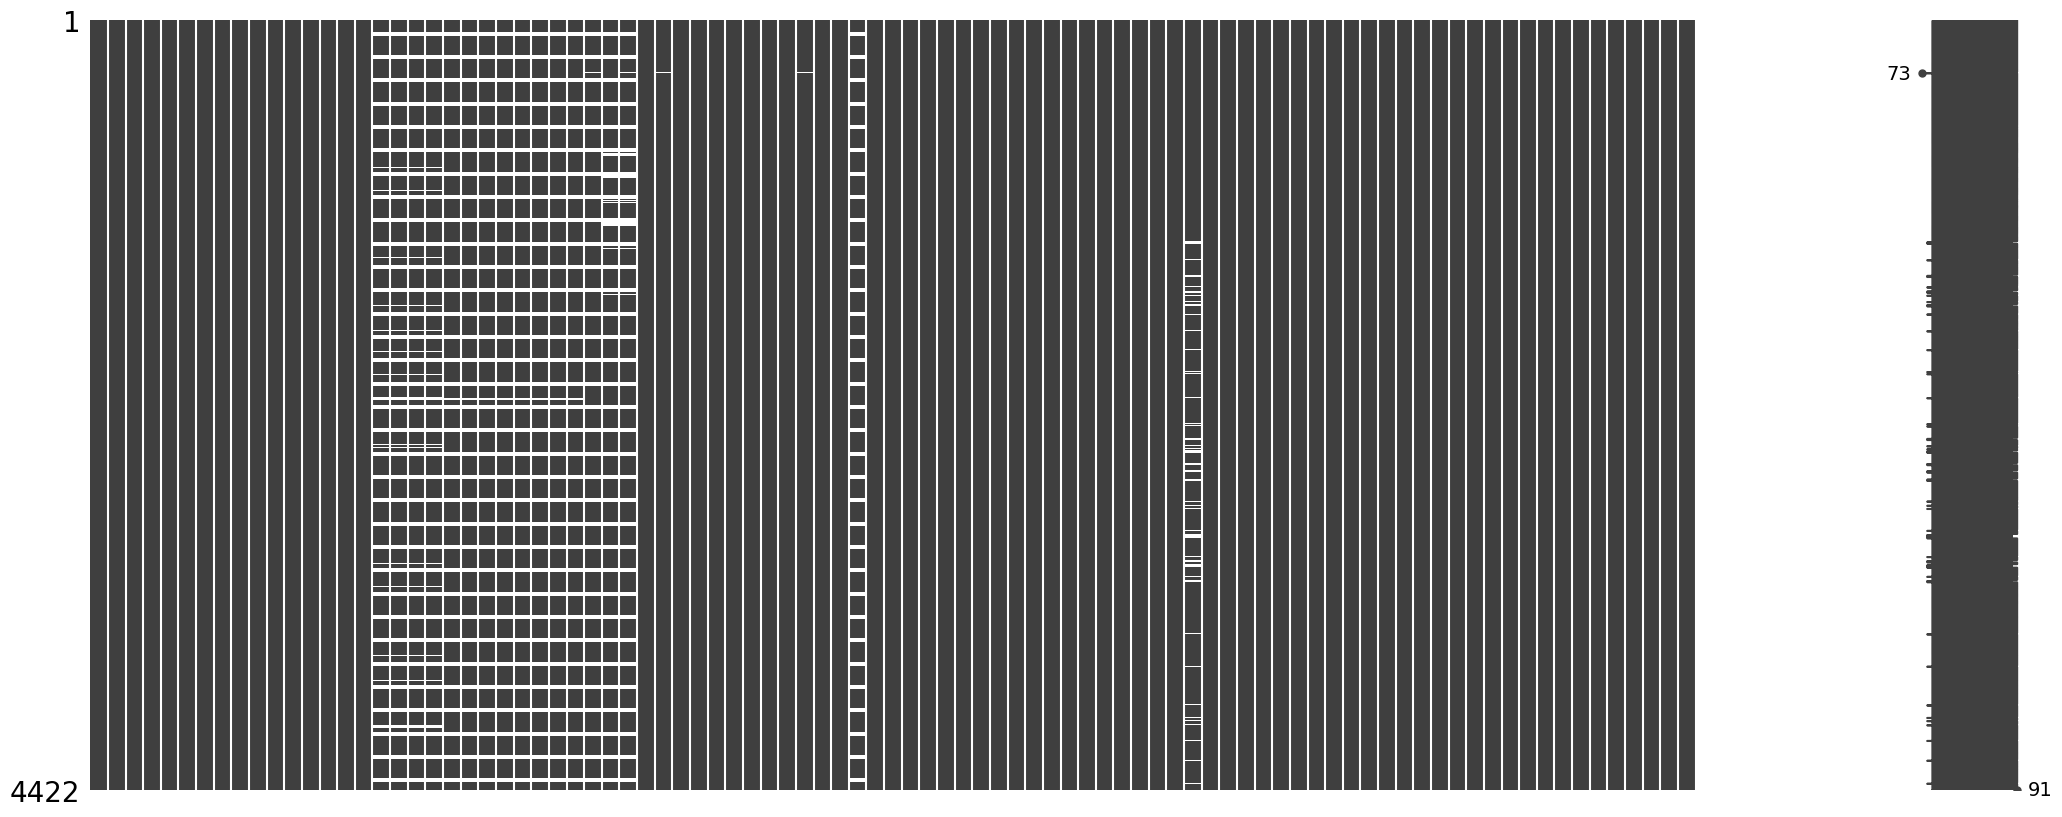

In [90]:
missingno.matrix(dataset)

In [91]:
df_economics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [92]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,9725.080000
1,EL301,2001,10452.130000
2,EL301,2002,11780.170000
3,EL301,2003,12522.310000
4,EL301,2004,13769.510000
...,...,...,...
1191,EL653,2018,3207.990000
1192,EL653,2019,3243.040000
1193,EL653,2020,2907.590000
1194,EL653,2021,3090.650000


In [93]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [94]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,9725.080000
1,EL301,2001,10452.130000
2,EL301,2002,11780.170000
3,EL301,2003,12522.310000
4,EL301,2004,13769.510000
...,...,...,...
1191,EL653,2018,3207.990000
1192,EL653,2019,3243.040000
1193,EL653,2020,2907.590000
1194,EL653,2021,3090.650000


In [95]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

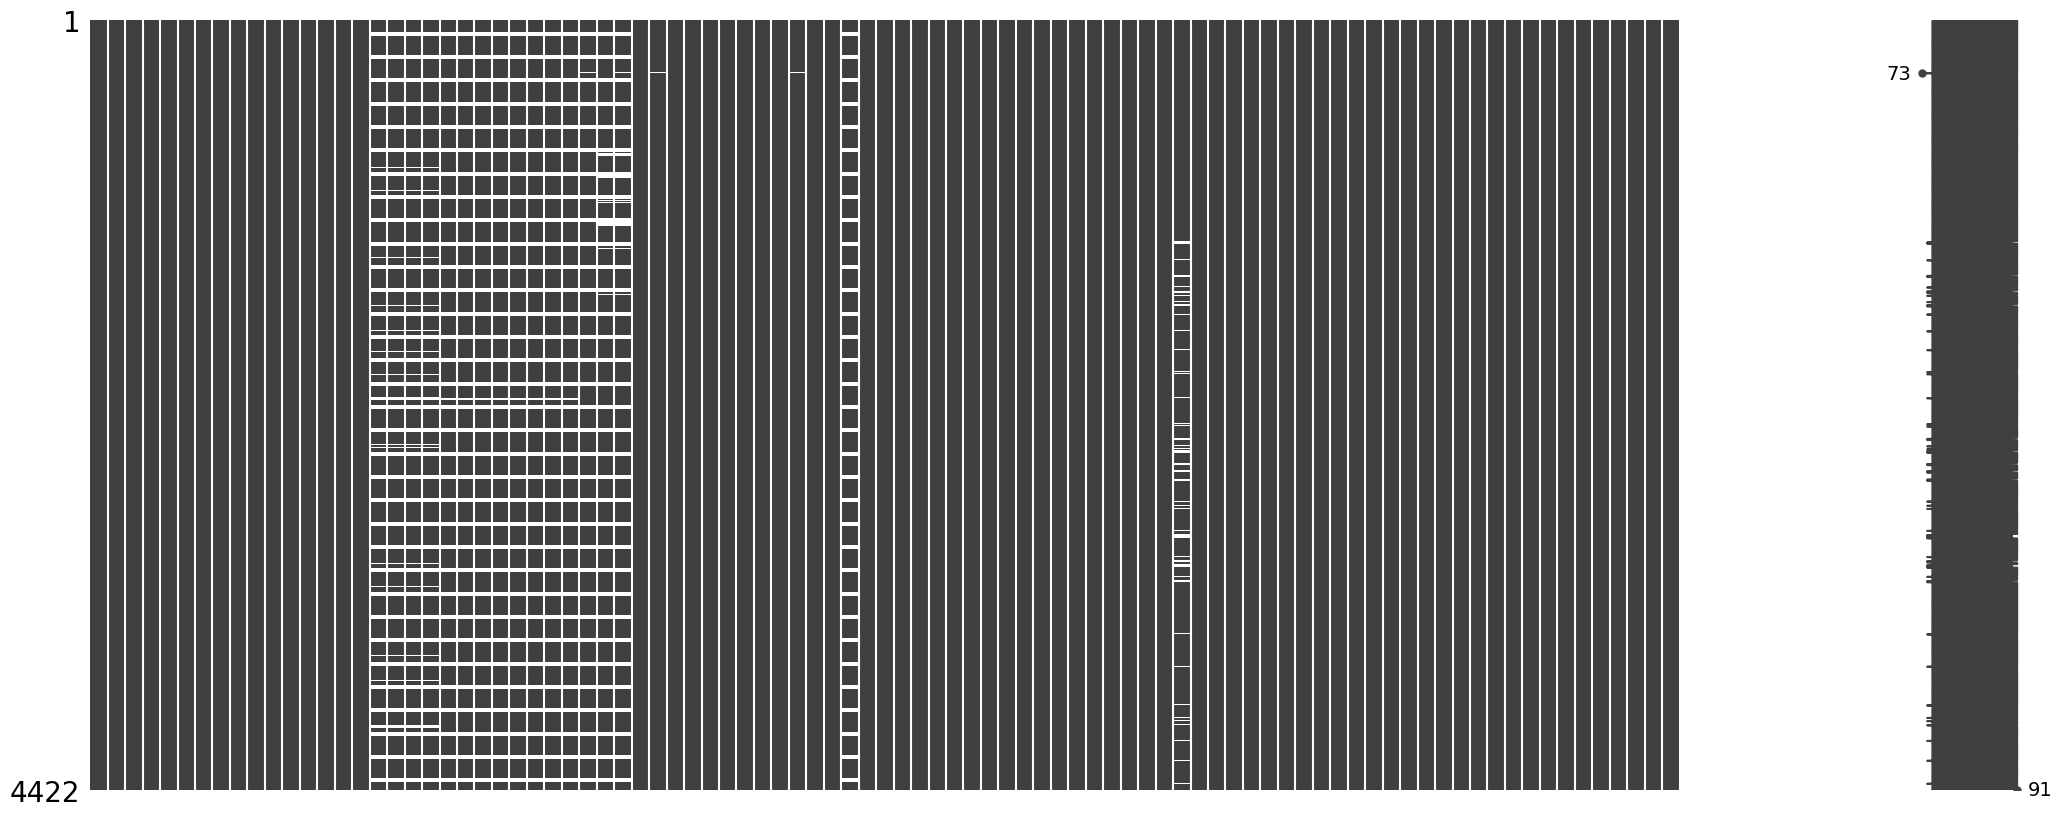

In [96]:
missingno.matrix(dataset)

In [97]:
df_trade = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [98]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
818,EL653,2019,3278.000000,3737.000000
819,EL653,2020,4572.000000,4962.000000
820,EL653,2021,3040.000000,3666.000000
821,EL653,2022,11830.000000,12294.000000


In [99]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [100]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
818,EL653,2019,3278.000000,3737.000000
819,EL653,2020,4572.000000,4962.000000
820,EL653,2021,3040.000000,3666.000000
821,EL653,2022,11830.000000,12294.000000


In [101]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

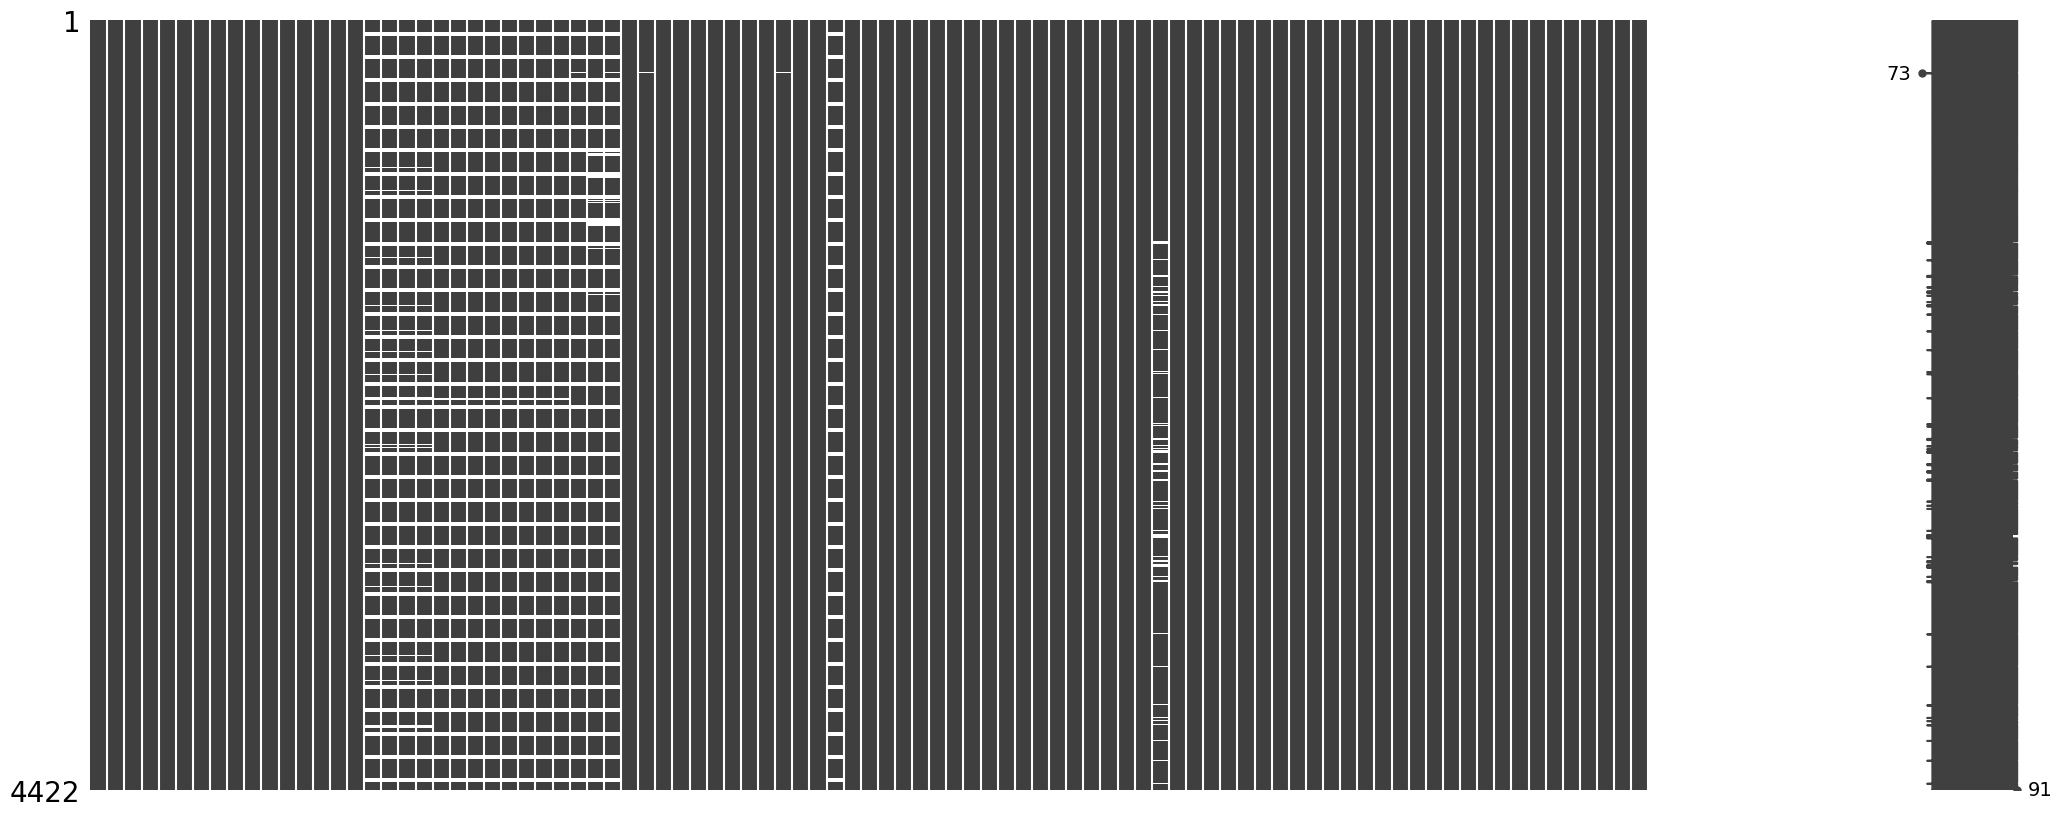

In [102]:
missingno.matrix(dataset)

In [103]:
missing = describe_dataframe(dataset, remove_zeros=True)

In [104]:
missing

,Column,Missing
16,ndvi,18.905500
17,ndmi,18.905500
18,ndwi,18.905500
19,ndbi,18.905500
20,ndvi_mean,16.892800
21,ndmi_mean,16.892800
22,ndwi_mean,16.892800
23,ndbi_mean,16.892800
24,ndvi_std,16.892800
25,ndmi_std,16.892800


In [105]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2025-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2025,1,0.432013,0.083407,-0.381338,-0.083407,0.389504,0.115818,-0.294944,-0.115818,0.061180,0.040032,0.066543,0.040032,14.328710,9.091290,11.710000,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,2.821613,0.890000,28.569999,87.469998,87.469998,87.469998,5.010000,15.710000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,13.916667,13.833333,57.638889,453.229155,26.000000,2.000000,24.000000,10.500000,17.333333,17.333333,10.500000,417.000000,270.000000,0.000000,146.344901,391.000000,26.000000,26.000000,391.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2025-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2025,2,0.403956,0.073849,-0.363431,-0.073849,0.389734,0.119886,-0.288719,-0.119886,0.050255,0.031638,0.054882,0.031638,10.381429,5.849286,8.115357,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,9.649285,120.549997,239.829994,270.709993,357.649991,270.179993,2.450000,15.090000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,13.916667,13.833333,57.638889,453.229155,26.000000,2.000000,24.000000,10.500000,17.333333,17.333333,10.500000,417.000000,270.000000,0.000000,146.344901,391.000000,26.000000,26.000000,391.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2025-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2025,3,0.419150,0.080605,-0.377346,-0.080605,0.411708,0.119997,-0.346138,-0.119997,0.050678,0.039874,0.067993,0.039874,15.805484,9.367419,12.586452,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,1.100645,8.750000,21.270000,33.899999,391.769990,34.119999,5.510000,21.930000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,13.916667,13.833333,57.638889,453.229155,26.000000,2.000000,24.000000,10.500000,17.333333,17.333333,10.500000,417.000000,270.000000,0.000000,146.344901,391.000000,26.000000,26.000000,391.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,2025-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2025,4,0.467388,0.108242,-0.423855,-0.108242,0.419608,0.112332,-0.375822,-0.112332,0.037769,0.032868,0.039894,0.032868,18.750741,11.136154,15.036923,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,0.812000,5.160000,7.050000,24.359999,416.129989,24.359999,5.890000,22.950000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,13.916667,13.8

In [106]:
dataset.reset_index(inplace=True, drop=True)

In [107]:
# dataset['cases'].value_counts()

In [108]:
# dataset['cases'].sum()

In [109]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2025-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2025,1,0.432013,0.083407,-0.381338,-0.083407,0.389504,0.115818,-0.294944,-0.115818,0.061180,0.040032,0.066543,0.040032,14.328710,9.091290,11.710000,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,2.821613,0.890000,28.569999,87.469998,87.469998,87.469998,5.010000,15.710000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,13.916667,13.833333,57.638889,453.229155,26.000000,2.000000,24.000000,10.500000,17.333333,17.333333,10.500000,417.000000,270.000000,0.000000,146.344901,391.000000,26.000000,26.000000,391.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2025-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2025,2,0.403956,0.073849,-0.363431,-0.073849,0.389734,0.119886,-0.288719,-0.119886,0.050255,0.031638,0.054882,0.031638,10.381429,5.849286,8.115357,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,9.649285,120.549997,239.829994,270.709993,357.649991,270.179993,2.450000,15.090000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,13.916667,13.833333,57.638889,453.229155,26.000000,2.000000,24.000000,10.500000,17.333333,17.333333,10.500000,417.000000,270.000000,0.000000,146.344901,391.000000,26.000000,26.000000,391.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2025-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2025,3,0.419150,0.080605,-0.377346,-0.080605,0.411708,0.119997,-0.346138,-0.119997,0.050678,0.039874,0.067993,0.039874,15.805484,9.367419,12.586452,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,1.100645,8.750000,21.270000,33.899999,391.769990,34.119999,5.510000,21.930000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,13.916667,13.833333,57.638889,453.229155,26.000000,2.000000,24.000000,10.500000,17.333333,17.333333,10.500000,417.000000,270.000000,0.000000,146.344901,391.000000,26.000000,26.000000,391.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,2025-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2025,4,0.467388,0.108242,-0.423855,-0.108242,0.419608,0.112332,-0.375822,-0.112332,0.037769,0.032868,0.039894,0.032868,18.750741,11.136154,15.036923,14.328710,10.381429,15.805484,18.750741,9.091290,5.849286,9.367419,11.136154,11.710000,8.115357,12.586452,14.943447,0.812000,5.160000,7.050000,24.359999,416.129989,24.359999,5.890000,22.950000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,13.916667,13.8

In [110]:
cols = dataset.columns

In [111]:
print(cols)


Index(['cell_number', 'dt_placement', 'NUTS1_ID', 'NUTS1_NAME', 'NUTS2_ID',
       'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME', 'x',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=102)


In [112]:
len(cols)

102

In [113]:
years = dataset.year.unique().tolist()

In [114]:
for item in years:
    dataset[dataset.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{item}.csv", encoding = enc, index = False)